In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path = "/content/drive/MyDrive/major project/Rice_Leaf_AUG/dataset"

In [4]:
import os
os.listdir(dataset_path)

['train', 'val', 'test']

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

img_size = (224, 224)
batch_size = 32

train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_gen.flow_from_directory(
    dataset_path + "/train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_data = test_gen.flow_from_directory(
    dataset_path + "/test",
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 2584 images belonging to 5 classes.
Found 65 images belonging to 5 classes.


In [6]:
from tensorflow.keras.applications import ResNet50, MobileNetV2

resnet = ResNet50(weights='imagenet', include_top=False, pooling='avg')
mobilenet = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/tmp/ipykernel_415/762359995.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
X_resnet_train = resnet.predict(train_data)
X_resnet_test = resnet.predict(test_data)

X_mobile_train = mobilenet.predict(train_data)
X_mobile_test = mobilenet.predict(test_data)

y_train = train_data.classes
y_test = test_data.classes

81/81 ━━━━━━━━━━━━━━━━━━━━ 1325s 16s/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 50s 431ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 6s/step


In [8]:
import numpy as np

X_train = np.concatenate((X_resnet_train, X_mobile_train), axis=1)
X_test = np.concatenate((X_resnet_test, X_mobile_test), axis=1)

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("Fusion + SVM Accuracy:", accuracy_score(y_test, y_pred))

Fusion + SVM Accuracy: 0.9692307692307692


In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        12
           2       0.92      0.92      0.92        13
           3       1.00      0.93      0.97        15
           4       0.91      1.00      0.95        10

    accuracy                           0.97        65
   macro avg       0.97      0.97      0.97        65
weighted avg       0.97      0.97      0.97        65



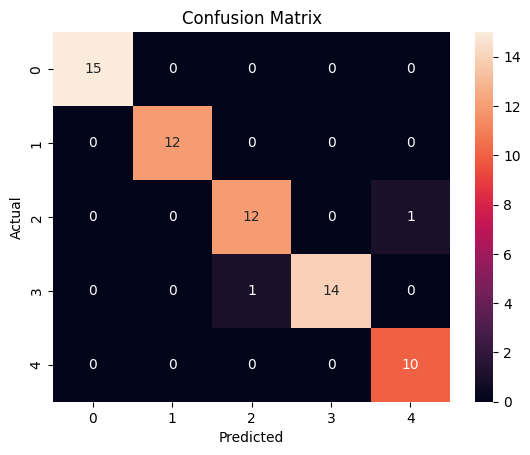

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()